# Analisis Exploratorio de Datos (EDA) Unificado
## Sistema de Prediccion de Factores de Riesgo en Adolescentes Salvadorenios (GSHS 2013)

Este notebook contiene dos secciones:
- **Seccion 1: EDA con variables Q** (respuestas originales Likert ordinal)
- **Seccion 2: EDA con variables QN** (recodificaciones binarias 0/1)

Ambas secciones analizan el mismo dataset pero desde perspectivas complementarias.

---
# SECCION 1: EDA con Variables Q (Originales)

Las variables Q1-Q58 contienen las respuestas originales de la encuesta GSHS en escala Likert ordinal (1-7).
Esta seccion replica el analisis exploratorio original del proyecto.

In [1]:
import sys
sys.path.append('../')

from src.data.cleaner import load_and_clean_survey, engineer_targets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# 1. Carga y limpieza automatica
ruta_cruda = '../data/raw/SLV2013_Public_Use.csv'
df_crudo = load_and_clean_survey(ruta_cruda)

# 2. Creacion automatica del IMC y del Riesgo de Salud Mental
df = engineer_targets(df_crudo)

print(f"Dimensiones del dataset listo para EDA: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head(3)

Cargado: 1915 filas x 104 columnas

IMC calculado: 1738 valores validos

Riesgo: Sin Riesgo=1703 | Con Riesgo=212

Dimensiones del dataset listo para EDA: 1915 filas y 106 columnas.


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,qnfrvgg,qnpa7g,qnpe5g,qnc1g,qnc2g,weight,stratum,psu,IMC,Riesgo_Salud_Mental
0,4.0,1.0,1.0,1.57,47.0,1.0,2.0,1.0,1.0,1.0,...,2.0,2.0,2.0,NaN,NaN,256.3443,201301006,11,19.067711,0
1,3.0,1.0,1.0,1.57,51.0,3.0,2.0,2.0,4.0,2.0,...,2.0,2.0,2.0,NaN,NaN,256.3443,201301006,11,20.690495,0
2,4.0,1.0,1.0,1.63,49.0,2.0,3.0,1.0,2.0,1.0,...,2.0,2.0,2.0,NaN,NaN,256.3443,201301006,11,18.442546,0


## 1. Carga de Datos y Tratamiento de la Anomalia Critica

El valor `1.79769313486232e+308` (maximo float64) se usa como missing value en encuestas procesadas en SPSS/Stata.
Se reemplaza por `NaN` para evitar corrupcion en calculos estadisticos.

In [2]:
valor_anomalo = 1.79769313486232e+308
df = df.replace(valor_anomalo, np.nan)
print("Anomalia extrema eliminada y reemplazada por valores nulos (np.nan).")

Anomalia extrema eliminada y reemplazada por valores nulos (np.nan).


## 2. Ingenieria de Variables: Target A (Regresion - IMC)

IMC = Peso(Q5) / Estatura(Q4)^2

Q4 y Q5 se excluyen de los predictores en la fase de modelado para evitar Data Leakage.

In [3]:
if 'Q5' in df.columns and 'Q4' in df.columns:
    df['IMC'] = df['Q5'] / (df['Q4'] ** 2)
    print("Variable objetivo 'IMC' creada exitosamente.")
    print(df['IMC'].describe())
else:
    print("Error: No se encontraron las columnas Q4 o Q5 en el dataset.")

Variable objetivo 'IMC' creada exitosamente.
count    1738.000000
mean       21.635691
std         4.144966
min        13.793103
25%        18.765247
50%        20.709409
75%        23.437500
max        46.777373
Name: IMC, dtype: float64


## 3. Ingenieria de Variables: Target B (Clasificacion - Riesgo de Salud Mental)

Variable binaria donde `1` = riesgo grave (Q25==1, ideacion suicida) y `0` = sin riesgo.

In [4]:
df['Riesgo_Salud_Mental'] = df['Q25'].apply(lambda x: 1 if x == 1 else 0)

distribucion_clases = df['Riesgo_Salud_Mental'].value_counts(normalize=True) * 100
print("Distribucion porcentual de la variable Riesgo_Salud_Mental:")
print(distribucion_clases)

Distribucion porcentual de la variable Riesgo_Salud_Mental:
Riesgo_Salud_Mental
0    88.929504
1    11.070496
Name: proportion, dtype: float64


## 4. Analisis Exploratorio Visual (Variables Q)

C:\Users\usuario\AppData\Local\Temp\ipykernel_14832\983440982.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Riesgo_Salud_Mental', palette='Set1', ax=axes[1])
C:\Users\usuario\AppData\Local\Temp\ipykernel_14832\983440982.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Q1', y='IMC', palette='Set3', ax=axes[2])


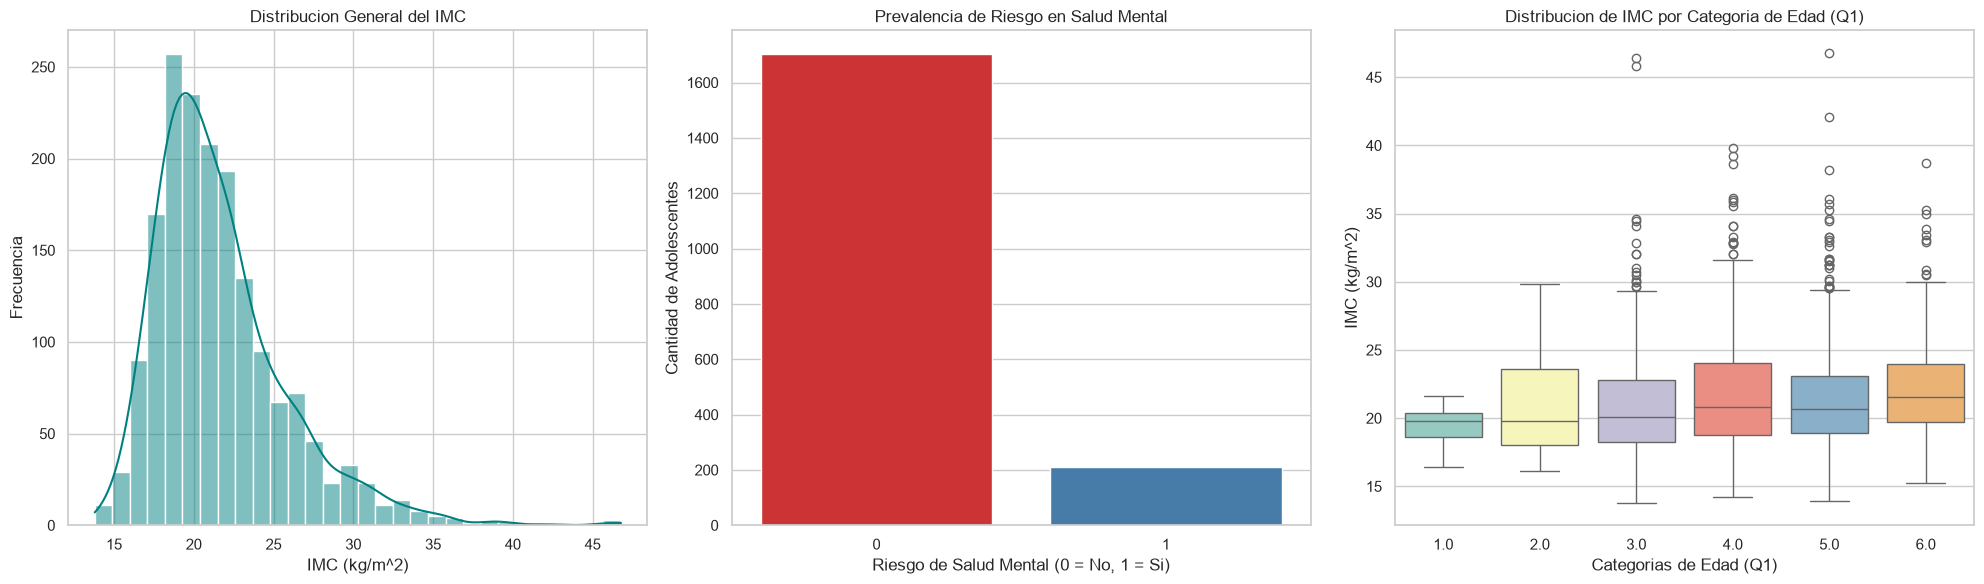

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histograma del IMC
sns.histplot(df['IMC'].dropna(), kde=True, bins=30, color='teal', ax=axes[0])
axes[0].set_title('Distribucion General del IMC')
axes[0].set_xlabel('IMC (kg/m^2)')
axes[0].set_ylabel('Frecuencia')

# Countplot del desbalance de clases
sns.countplot(data=df, x='Riesgo_Salud_Mental', palette='Set1', ax=axes[1])
axes[1].set_title('Prevalencia de Riesgo en Salud Mental')
axes[1].set_xlabel('Riesgo de Salud Mental (0 = No, 1 = Si)')
axes[1].set_ylabel('Cantidad de Adolescentes')

# Boxplot IMC por edad
sns.boxplot(data=df, x='Q1', y='IMC', palette='Set3', ax=axes[2])
axes[2].set_title('Distribucion de IMC por Categoria de Edad (Q1)')
axes[2].set_xlabel('Categorias de Edad (Q1)')
axes[2].set_ylabel('IMC (kg/m^2)')

plt.tight_layout()
plt.show()

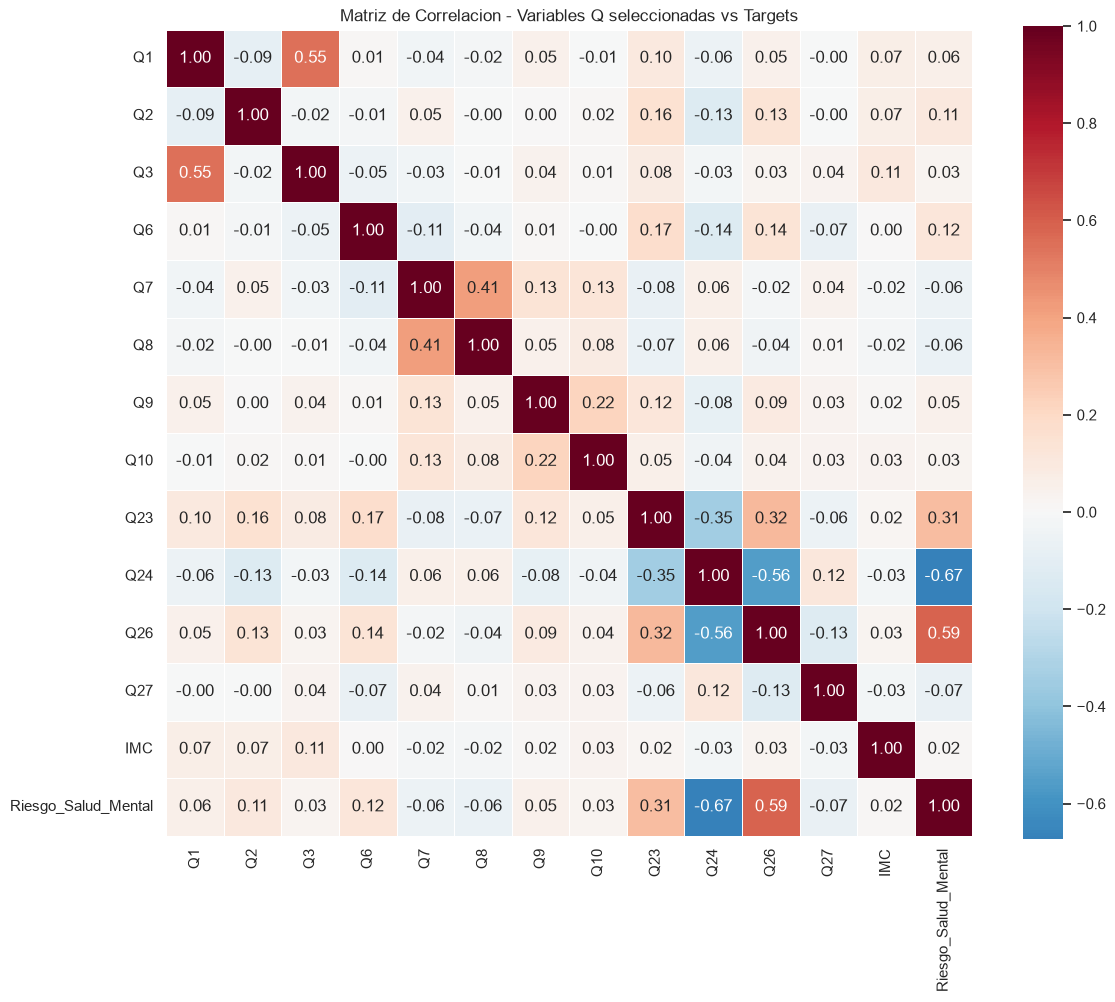

In [6]:
# Matriz de correlacion de variables Q seleccionadas con los targets
q_cols_sample = ['Q1', 'Q2', 'Q3', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q23', 'Q24', 'Q26', 'Q27']
q_available = [c for c in q_cols_sample if c in df.columns]
corr_q = df[q_available + ['IMC', 'Riesgo_Salud_Mental']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_q, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Matriz de Correlacion - Variables Q seleccionadas vs Targets')
plt.tight_layout()
plt.show()

## 5. Exportacion del Dataset Limpio

In [7]:
ruta_procesada = '../data/processed/SLV2013_Limpios_Targets.csv'
df.to_csv(ruta_procesada, index=False)

print(f"Dataset exportado a '{ruta_procesada}'")
print(f"Archivo listo con {df.shape[0]} registros.")

Dataset exportado a '../data/processed/SLV2013_Limpios_Targets.csv'
Archivo listo con 1915 registros.


---
# SECCION 2: EDA con Variables QN (Recodificadas Binarias)

Las variables QN6-QN58 son recodificaciones binarias (0/1) de las variables Q originales.
Cada QN indica si el estudiante cumple o no una condicion especifica.

**Ventajas de QN sobre Q:**
- Menor dimensionalidad (sin OHE necesario)
- Interpretacion directa (0 = no cumple, 1 = cumple)
- Evita asumir equidistancia entre categorias ordinales

**Limitacion conocida:**
- Pierde granularidad ordinal (ej: Q7 tiene 7 niveles de consumo de frutas, QN7 solo indica si consume 1+/dia)

In [8]:
import json
from src.features.engineering import QN_FEATURE_COLS, Q_FEATURE_COLS, load_codebook

# Cargar codebook para etiquetas legibles
codebook = load_codebook('../data/codebook.json')

# Seleccionar columnas QN del dataset
qn_cols = [c for c in QN_FEATURE_COLS if c in df.columns]
print(f"Variables QN disponibles: {len(qn_cols)}")
print(f"Variables Q disponibles: {len([c for c in Q_FEATURE_COLS if c in df.columns])}")

Variables QN disponibles: 43
Variables Q disponibles: 46


## 6. Distribucion de Variables QN (Proporcion 0/1)

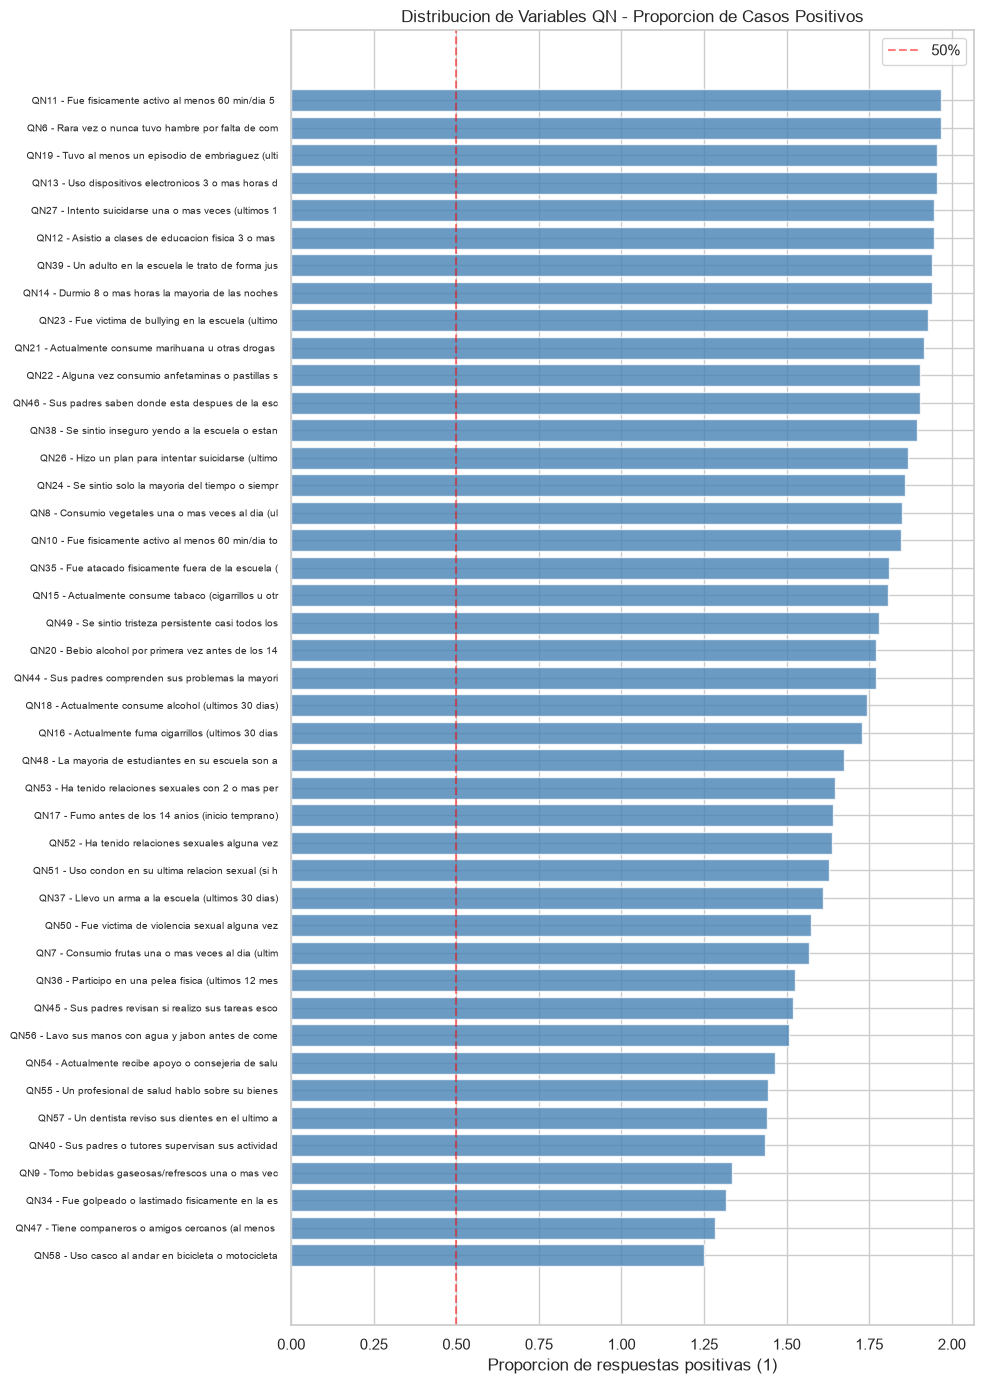

In [9]:
# Calcular proporcion de 1s para cada QN
qn_means = df[qn_cols].mean().sort_values(ascending=True)

# Etiquetas legibles del codebook
labels = [f"{col} - {codebook.get(col, col)[:45]}" for col in qn_means.index]

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(range(len(qn_means)), qn_means.values, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('Proporcion de respuestas positivas (1)')
ax.set_title('Distribucion de Variables QN - Proporcion de Casos Positivos')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Valores Nulos en Variables QN

Top 10 variables QN con mayor porcentaje de nulos:
QN40    88.355091
QN47    82.610966
QN48    82.506527
QN21    81.879896
QN45    81.723238
QN37    81.044386
QN36    78.694517
QN18    76.501305
QN19    76.031332
QN34    65.326371


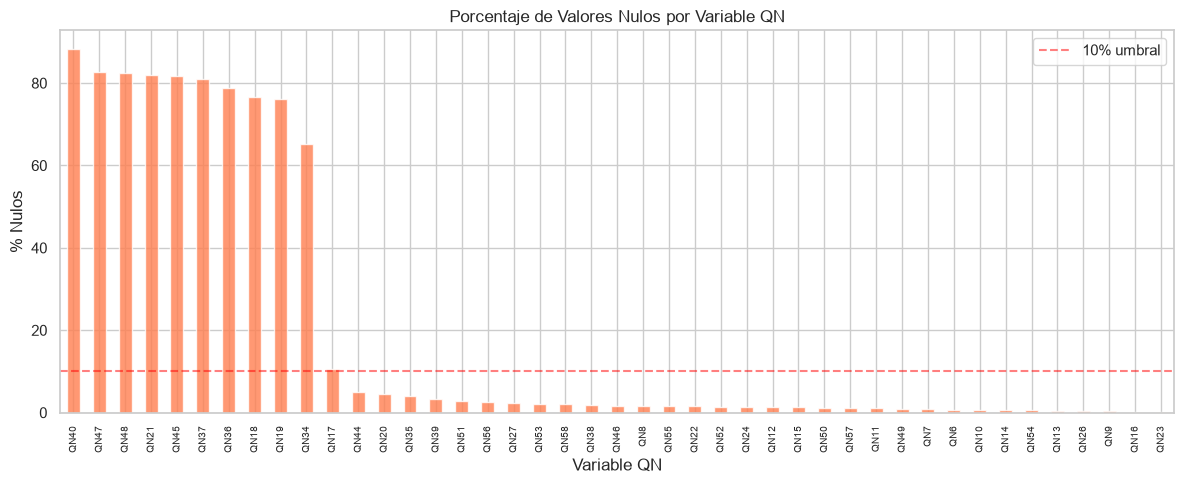

In [10]:
# Porcentaje de nulos por variable QN
null_pct = (df[qn_cols].isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Top 10 variables QN con mayor porcentaje de nulos:")
print(null_pct.head(10).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
null_pct.plot(kind='bar', ax=ax, color='coral', alpha=0.8)
ax.set_title('Porcentaje de Valores Nulos por Variable QN')
ax.set_ylabel('% Nulos')
ax.set_xlabel('Variable QN')
ax.axhline(y=10, color='red', linestyle='--', alpha=0.5, label='10% umbral')
ax.legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

## 8. Correlacion QN con Targets

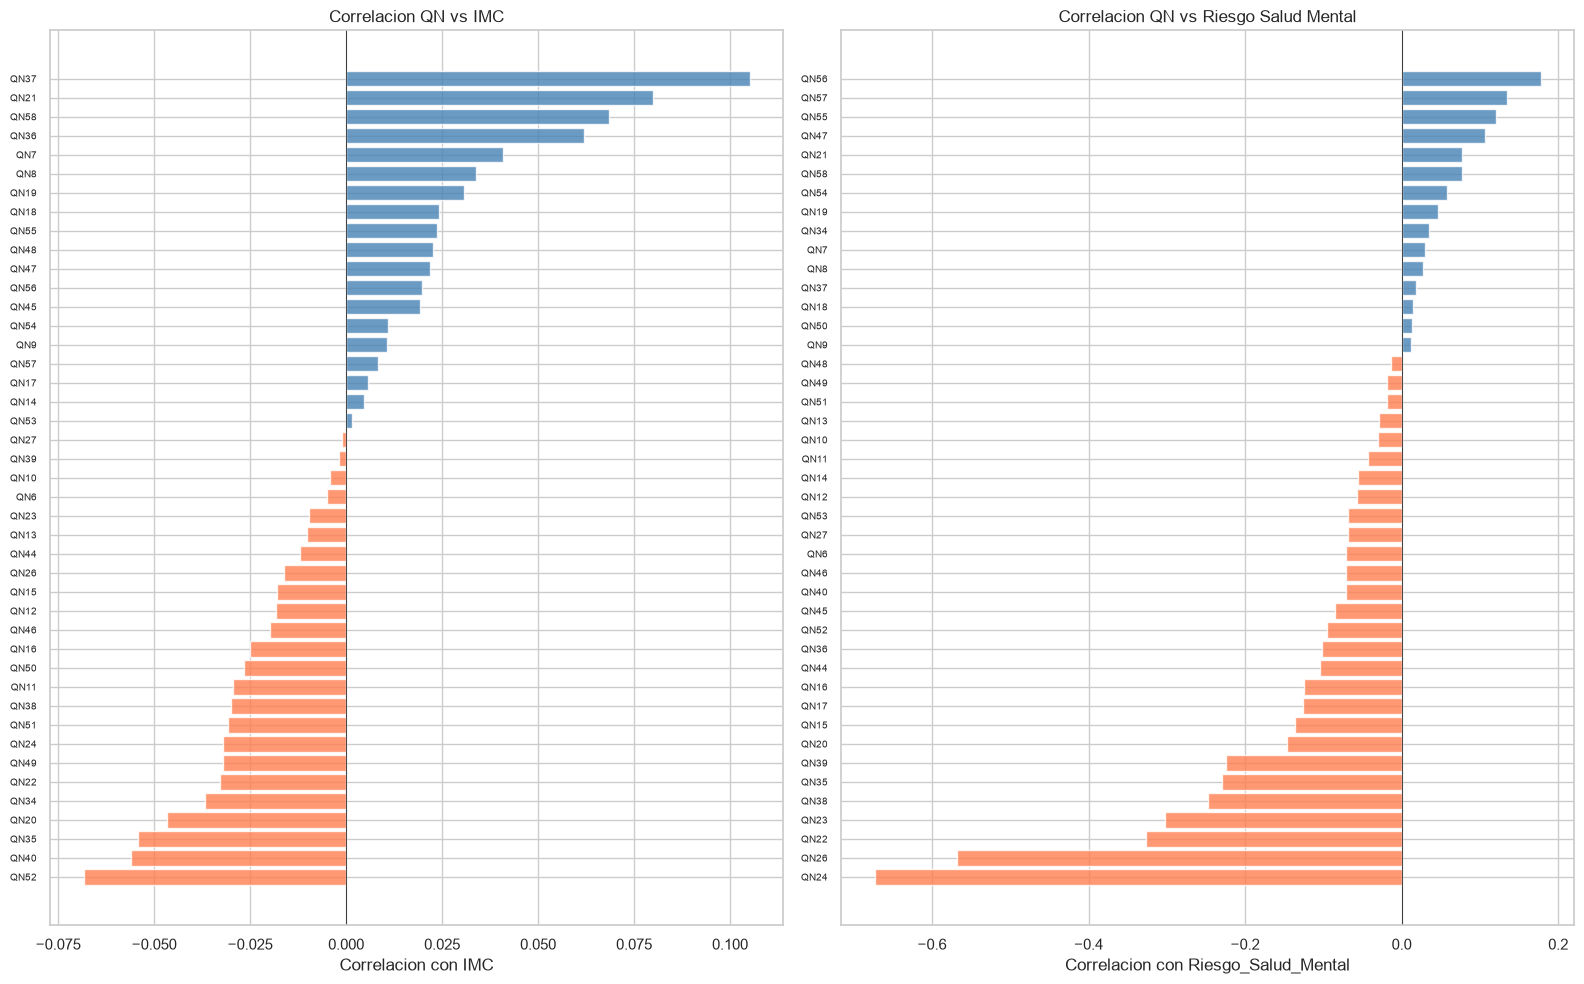

In [11]:
# Correlacion de cada QN con ambos targets
corr_imc = df[qn_cols + ['IMC']].corr()['IMC'].drop('IMC').sort_values()
corr_risk = df[qn_cols + ['Riesgo_Salud_Mental']].corr()['Riesgo_Salud_Mental'].drop('Riesgo_Salud_Mental').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Correlacion con IMC
colors_imc = ['coral' if v < 0 else 'steelblue' for v in corr_imc.values]
axes[0].barh(range(len(corr_imc)), corr_imc.values, color=colors_imc, alpha=0.8)
axes[0].set_yticks(range(len(corr_imc)))
axes[0].set_yticklabels(corr_imc.index, fontsize=7)
axes[0].set_xlabel('Correlacion con IMC')
axes[0].set_title('Correlacion QN vs IMC')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# Correlacion con Riesgo_Salud_Mental
colors_risk = ['coral' if v < 0 else 'steelblue' for v in corr_risk.values]
axes[1].barh(range(len(corr_risk)), corr_risk.values, color=colors_risk, alpha=0.8)
axes[1].set_yticks(range(len(corr_risk)))
axes[1].set_yticklabels(corr_risk.index, fontsize=7)
axes[1].set_xlabel('Correlacion con Riesgo_Salud_Mental')
axes[1].set_title('Correlacion QN vs Riesgo Salud Mental')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## 9. Comparativa Q vs QN: Heatmaps de Correlacion

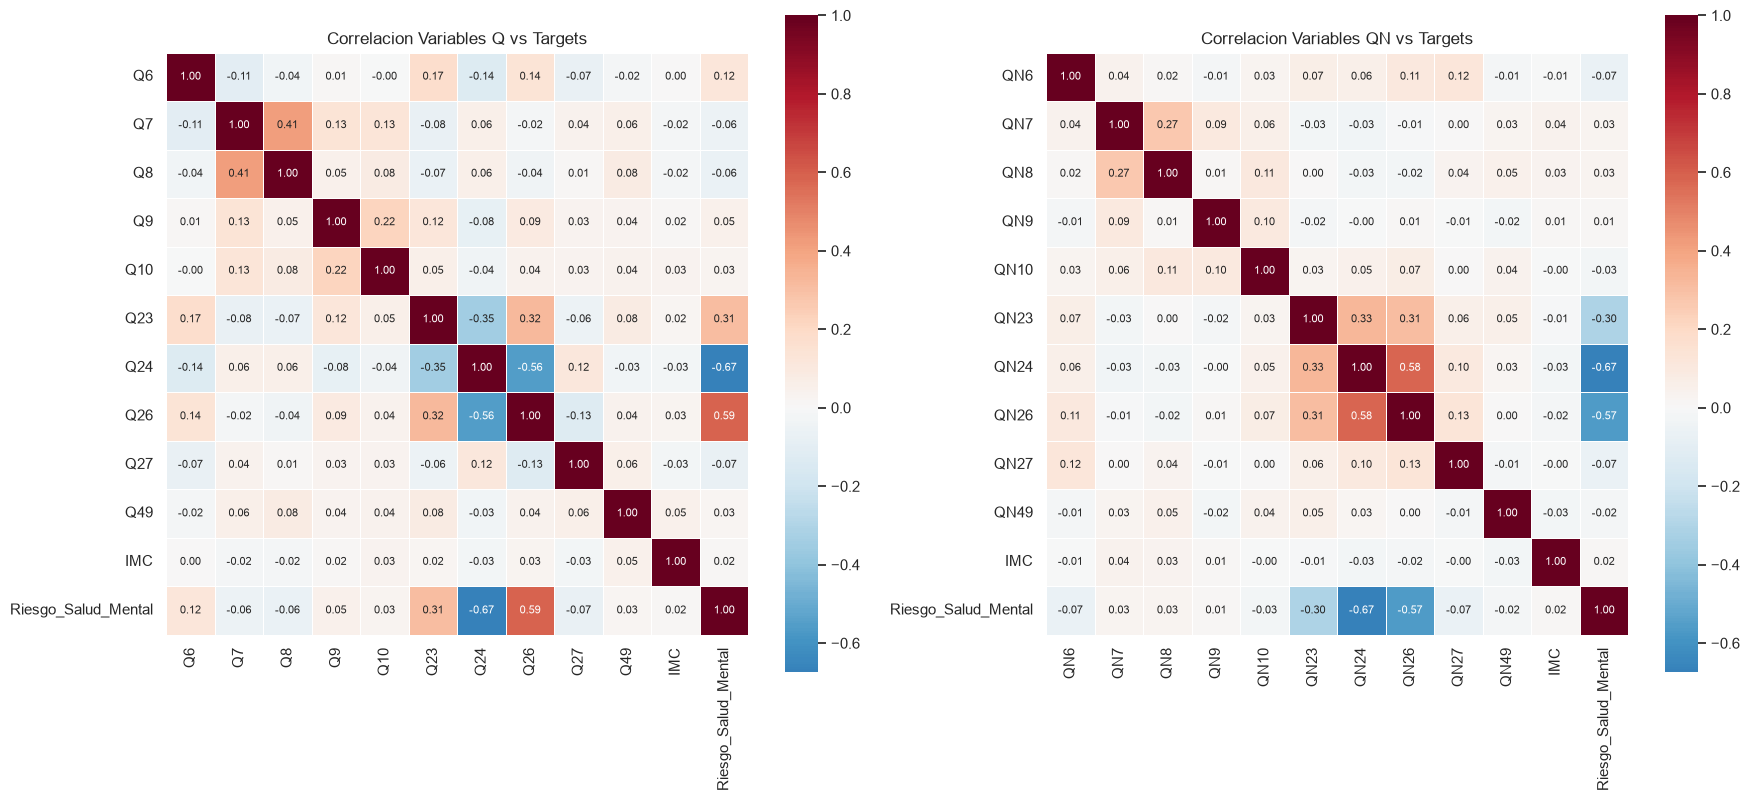

In [12]:
# Seleccion de variables Q y QN con mismo numero para comparar
common_nums = [6, 7, 8, 9, 10, 23, 24, 26, 27, 49]
q_subset = [f'Q{n}' for n in common_nums if f'Q{n}' in df.columns]
qn_subset = [f'QN{n}' for n in common_nums if f'QN{n}' in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Correlacion Q
corr_q_sub = df[q_subset + ['IMC', 'Riesgo_Salud_Mental']].corr()
sns.heatmap(corr_q_sub, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], square=True, linewidths=0.5, annot_kws={'size': 8})
axes[0].set_title('Correlacion Variables Q vs Targets')

# Correlacion QN
corr_qn_sub = df[qn_subset + ['IMC', 'Riesgo_Salud_Mental']].corr()
sns.heatmap(corr_qn_sub, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], square=True, linewidths=0.5, annot_kws={'size': 8})
axes[1].set_title('Correlacion Variables QN vs Targets')

plt.tight_layout()
plt.show()

## 10. Resumen Estadistico

Comparacion de la capacidad predictiva de Q vs QN para cada target.

In [13]:
# Top 5 variables mas correlacionadas con cada target (Q y QN)
q_avail = [c for c in Q_FEATURE_COLS if c in df.columns]

print("=" * 60)
print("TOP 5 VARIABLES MAS CORRELACIONADAS CON IMC")
print("=" * 60)
for prefix, cols in [('Q', q_avail), ('QN', qn_cols)]:
    corr = df[cols + ['IMC']].corr()['IMC'].drop('IMC').abs().sort_values(ascending=False)
    print(f"\n{prefix}:")
    for col, val in corr.head(5).items():
        desc = codebook.get(col, col)[:50]
        print(f"  {col:>5} ({val:.3f}) - {desc}")

print("\n" + "=" * 60)
print("TOP 5 VARIABLES MAS CORRELACIONADAS CON RIESGO SALUD MENTAL")
print("=" * 60)
for prefix, cols in [('Q', q_avail), ('QN', qn_cols)]:
    corr = df[cols + ['Riesgo_Salud_Mental']].corr()['Riesgo_Salud_Mental'].drop('Riesgo_Salud_Mental').abs().sort_values(ascending=False)
    print(f"\n{prefix}:")
    for col, val in corr.head(5).items():
        desc = codebook.get(col, col)[:50]
        print(f"  {col:>5} ({val:.3f}) - {desc}")

TOP 5 VARIABLES MAS CORRELACIONADAS CON IMC

Q:
     Q3 (0.110) - Grado escolar que cursa actualmente
    Q52 (0.078) - Ha tenido relaciones sexuales alguna vez
    Q22 (0.072) - Frecuencia de consumo de anfetaminas sin prescripc
     Q2 (0.067) - Sexo del estudiante (1=masculino, 2=femenino)
     Q1 (0.067) - Edad del estudiante

QN:
   QN37 (0.105) - Llevo un arma a la escuela (ultimos 30 dias)
   QN21 (0.080) - Actualmente consume marihuana u otras drogas ilici
   QN58 (0.069) - Uso casco al andar en bicicleta o motocicleta la m
   QN52 (0.068) - Ha tenido relaciones sexuales alguna vez
   QN36 (0.062) - Participo en una pelea fisica (ultimos 12 meses)

TOP 5 VARIABLES MAS CORRELACIONADAS CON RIESGO SALUD MENTAL

Q:
    Q24 (0.674) - Frecuencia de sentirse solo (ultimos 12 meses)
    Q26 (0.592) - Frecuencia de plan de intento de suicidio (ultimos
    Q22 (0.315) - Frecuencia de consumo de anfetaminas sin prescripc
    Q23 (0.307) - Dias victima de bullying en la escuela (ultimos 30